In [1]:
!pip install tensorboardX rdkit
!pip install rdkit-pypi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 2.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 57.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 62.7 MB/s eta 0:00:00:00:0100:01


In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as Data
torch.manual_seed(8) # for reproduce
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneOut



import time
import numpy as np
import gc
import sys
sys.path.append('/notebooks/data/')
sys.setrecursionlimit(50000)
import pickle
torch.backends.cudnn.benchmark = True
torch.set_default_tensor_type('torch.cuda.FloatTensor')
from tensorboardX import SummaryWriter
torch.nn.Module.dump_patches = True
import copy
import pandas as pd
#then import my own modules
from AttentiveFP import Fingerprint, Fingerprint_viz, save_smiles_dicts, get_smiles_dicts, get_smiles_array, moltosvg_highlight

from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
# from rdkit.Chem import rdMolDescriptors, MolSurf
# from rdkit.Chem.Draw import SimilarityMaps
from rdkit import Chem
# from rdkit.Chem import AllChem
from rdkit.Chem import QED
%matplotlib inline
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
from IPython.display import SVG, display
import seaborn as sns; sns.set(color_codes=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.11/dist-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [2]:
# Get a csv file with the sisometric smiles strings and sets up the datframe and the model. 

per_target_output_units_num = 2 # 2 Because it is a classificaiton problem with two possible out comes

def process_smiles_data_and_setup_model(raw_filename, targets, batch_size=50, epochs=800, p_dropout=0.1, 
                                        fingerprint_dim=150, radius=3, T=3, weight_decay=2, learning_rate=3):
    
    
        """
    Process SMILES data and set up a neural network model for molecular property prediction.
    
    Parameters:
    -----------
    raw_filename : str
        Path to the CSV file containing SMILES and target data
    targets : list
        List of target column names to predict
    batch_size : int, default=50
        Number of samples per training batch
    epochs : int, default=800
        Number of training epochs
    p_dropout : float, default=0.1
        Dropout probability for regularization
    fingerprint_dim : int, default=150
        Dimension of molecular fingerprint
    radius : int, default=3
        Size of atomic neighborhood considered
    T : int, default=3
        Number of message passing steps
    weight_decay : int, default=2
        L2 regularization parameter (10^-weight_decay)
    learning_rate : int, default=3
        Learning rate for optimization (10^-learning_rate)
    """
        
        
        
    feature_filename = raw_filename.replace('.csv', '.pickle')
    prefix_filename = raw_filename.split('/')[-1].replace('.csv', '')
    smiles_targets_df = pd.read_csv(raw_filename)


    for column in targets:
        smiles_targets_df[column] = smiles_targets_df[column].apply(lambda x: 1 if x > 0 else 0)

    smilesList = smiles_targets_df.SMILES.values
    remained_smiles = []
    canonical_smiles_list = []
    
    for smiles in smilesList:
        try:
            mol = Chem.MolFromSmiles(smiles)
            remained_smiles.append(smiles)
            canonical_smiles_list.append(Chem.MolToSmiles(Chem.MolFromSmiles(smiles), isomericSmiles=True))
        except:
            print("not successfully processed smiles: ", smiles)
            pass
    
    smiles_targets_df = smiles_targets_df[smiles_targets_df["SMILES"].isin(remained_smiles)]
    smiles_targets_df['cano_smiles'] = canonical_smiles_list

    # Remove smiles with more than 150 atoms
    smilesList = [smiles for smiles in canonical_smiles_list if len(Chem.MolFromSmiles(smiles).GetAtoms()) < 151]
    uncovered = [smiles for smiles in canonical_smiles_list if len(Chem.MolFromSmiles(smiles).GetAtoms()) > 150]
    smiles_targets_df = smiles_targets_df[~smiles_targets_df["cano_smiles"].isin(uncovered)]

    # Load or save feature dictionary
    if os.path.isfile(feature_filename):
        feature_dicts = pickle.load(open(feature_filename, "rb"))
    else:
        feature_dicts = save_smiles_dicts(smilesList, raw_filename.replace('.csv', ''))

    remained_df = smiles_targets_df[smiles_targets_df["cano_smiles"].isin(feature_dicts['smiles_to_atom_mask'].keys())]
    uncovered_df = smiles_targets_df.drop(remained_df.index)

    # Raise warning if uncovered_df is not empty
    if not uncovered_df.empty:
        warnings.warn(f"There are {len(uncovered_df)} uncovered SMILES in the dataset.", UserWarning)

    # Calculate weights
    weights = []
    for target in targets:
        negative_df = remained_df[remained_df[target] == 0][["cano_smiles", target]]
        positive_df = remained_df[remained_df[target] == 1][["cano_smiles", target]]
        try:
            weights.append([(positive_df.shape[0] + negative_df.shape[0]) / negative_df.shape[0],
                            (positive_df.shape[0] + negative_df.shape[0]) / positive_df.shape[0]])
        except:
            weights.append([1, 1])

    # Model parameters
    per_target_output_units_num = 2
    output_units_num = len(targets) * per_target_output_units_num

    # Get sample data to determine feature dimensions
    x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, smiles_to_rdkit_list = get_smiles_array([canonical_smiles_list[0]], feature_dicts)
    num_atom_features = x_atom.shape[-1]
    num_bond_features = x_bonds.shape[-1]

    # Setup model and optimizer
    model = Fingerprint(radius, T, num_atom_features, num_bond_features,
                        fingerprint_dim, output_units_num, p_dropout)
    model.cuda()

    optimizer = optim.Adam(model.parameters(), 10**-learning_rate, weight_decay=10**-weight_decay)
    
    model_parameters = filter(lambda p: p.requires_grad, model.parameters())
    params = sum([np.prod(p.size()) for p in model_parameters])
    print(f"Number of parameters: {params}")

    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name}: {param.data.shape}")

    # Loss functions
    loss_functions = [nn.CrossEntropyLoss(torch.Tensor(weight), reduction='mean') for weight in weights]

    return (smiles_targets_df, feature_dicts, model, optimizer, loss_functions, 
            remained_df, canonical_smiles_list, batch_size, epochs)


raw_filename = '/notebooks/data/categorical_overall_median.csv'
targets = ['H3K4', 'H3K4ac', 'H3K4me1', 'H3K4me2', 'H3K4me3', 'H3K9me3', 'H3R2me2a', 'H3R2me2s']

smiles_targets_df, feature_dicts, model, optimizer, loss_function, remained_df, canonical_smiles_list, batch_size, epochs = process_smiles_data_and_setup_model(raw_filename, targets)


Number of parameters: 651320
atom_fc.weight: torch.Size([150, 39])
atom_fc.bias: torch.Size([150])
neighbor_fc.weight: torch.Size([150, 49])
neighbor_fc.bias: torch.Size([150])
gru_cells.0.weight_ih: torch.Size([450, 150])
gru_cells.0.weight_hh: torch.Size([450, 150])
gru_cells.0.bias_ih: torch.Size([450])
gru_cells.0.bias_hh: torch.Size([450])
gru_cells.1.weight_ih: torch.Size([450, 150])
gru_cells.1.weight_hh: torch.Size([450, 150])
gru_cells.1.bias_ih: torch.Size([450])
gru_cells.1.bias_hh: torch.Size([450])
gru_cells.2.weight_ih: torch.Size([450, 150])
gru_cells.2.weight_hh: torch.Size([450, 150])
gru_cells.2.bias_ih: torch.Size([450])
gru_cells.2.bias_hh: torch.Size([450])
align_layers.0.weight: torch.Size([1, 300])
align_layers.0.bias: torch.Size([1])
align_layers.1.weight: torch.Size([1, 300])
align_layers.1.bias: torch.Size([1])
align_layers.2.weight: torch.Size([1, 300])
align_layers.2.bias: torch.Size([1])
attend_layers.0.weight: torch.Size([150, 150])
attend_layers.0.bias: t

In [ ]:
def train(model, sample, optimizer, loss_function, targets, per_target_output_units_num):
    
    """
    Parameters:

    model: Neural network model instance for molecular property prediction
    sample: Data object containing SMILES representation and target values
    optimizer: PyTorch optimizer instance for model parameter updates
    loss_function: List of loss functions for each target
    targets: List of target properties to predict
    per_target_output_units_num: Number of output units per target

Input Requirements:

    Sample must contain canonical SMILES string (cano_smiles)
    Sample must contain target values for each property in targets
    Model must be compatible with molecular graph input format
    All tensors must be compatible with the specified device (CPU/GPU)

Output:

    Returns a single float value representing the training loss for this step

Key Operations:

    Converts SMILES to graph representation
    Performs forward pass through the model
    Calculates loss for each target property
    Performs backpropagation
    Updates model parameters
    """
    
    model.train()
    optimizer.zero_grad()
    
    x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array([sample.cano_smiles], feature_dicts)
    atoms_prediction, mol_prediction = model(torch.Tensor(x_atom).to(device), 
                                             torch.Tensor(x_bonds).to(device),
                                             torch.LongTensor(x_atom_index).to(device),
                                             torch.LongTensor(x_bond_index).to(device),
                                             torch.Tensor(x_mask).to(device))
    
    loss = 0.0
    for i, target in enumerate(targets):
        y_pred = mol_prediction[:, i * per_target_output_units_num:(i + 1) * per_target_output_units_num]
        y_val = sample[target]  # Changed this line

        if y_val in [0, 1]:
            y_val = torch.LongTensor([y_val]).to(device)
            loss += loss_function[i](y_pred, y_val)

    loss.backward()
    optimizer.step()
    return loss.item()


def eval(model, sample, targets, per_target_output_units_num):
    
    """
    Parameters:

    model: Trained neural network model instance
    sample: Data object containing SMILES representation
    targets: List of target properties to predict
    per_target_output_units_num: Number of output units per target

    Input Requirements:

    Sample must contain canonical SMILES string (cano_smiles)
    Model must be in evaluation mode
    All tensors must be compatible with the specified device (CPU/GPU)

    Output:

    Returns a list of float values, where each value is a probability prediction (between 0 and 1) for each target property
    Predictions are softmax probabilities for the positive class (class 1)

    Key Operations:
    
    Disables gradient computation
    Converts SMILES to graph representation
    Performs forward pass through the model
    Applies softmax to get probability predictions
    Returns predictions for all target properties
    """
    
    model.eval()
    with torch.no_grad():
        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array([sample.cano_smiles], feature_dicts)
        atoms_prediction, mol_prediction = model(torch.Tensor(x_atom).to(device), 
                                                 torch.Tensor(x_bonds).to(device),
                                                 torch.LongTensor(x_atom_index).to(device),
                                                 torch.LongTensor(x_bond_index).to(device),
                                                 torch.Tensor(x_mask).to(device))
        
        predictions = []
        for i, target in enumerate(targets):
            y_pred = mol_prediction[:, i * per_target_output_units_num:(i + 1) * per_target_output_units_num]
            y_pred =  F.softmax(y_pred, dim=-1).cpu().numpy()[0, 1]
            predictions.append(y_pred)
        
    return predictions  # This is now a list of predictions, one for each target




def train_test_loop(remained_df, model, optimizer, loss_function, targets, per_target_output_units_num, num_epochs, patience=10):
"""  
    General Explanation:
    This function implements a Leave-One-Out Cross-Validation (LOOCV) training and evaluation pipeline for a molecular property prediction model. It trains the model multiple times, each time leaving out one sample for testing, and collects performance metrics. Parameters:

    remained_df: DataFrame containing molecular data and target values
    model: Neural network model instance
    optimizer: PyTorch optimizer instance
    loss_function: Loss functions for training
    targets: List of target properties to predict
    per_target_output_units_num: Number of output units per target
    num_epochs: Maximum number of training epochs
    patience: Number of epochs to wait before early stopping (default=10)

    Input Requirements:

    DataFrame must contain:
        'Host' column with SMILES strings
        Columns for each target property
        'cano_smiles' column
    Model must be compatible with molecular graph input
    All tensors must be compatible with specified device

    Output:
    Returns a tuple containing:

    roc_auc_scores: List of ROC-AUC scores for each target
    classification: Dictionary containing detailed predictions:
        Keys: Host SMILES
        Values: Dictionary of targets with (raw_output, threshold, true_label)

    Key Operations:

    Implements Leave-One-Out Cross-Validation
    Performs model training with early stopping
    Maintains best model based on validation loss
    Collects predictions and true labels
    Calculates ROC-AUC scores for model evaluation
"""

    
    loo = LeaveOneOut()
    all_predictions = [[] for _ in targets]
    all_true_labels = [[] for _ in targets]
    all_Hosts = []
    
    # Create the classification dictionary
    classification = {}
    
    for train_index, test_index in loo.split(remained_df):
        print(test_index)
        train_data = remained_df.iloc[train_index]
        test_sample = remained_df.iloc[test_index].squeeze()
        
        # Reset model for each fold
        model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
        '''Uncomment to see the initial model prameters
        print("Model parameters after reset:")
        for name, param in model.named_parameters():
            print(f"{name}: {param.data.sum().item():.4f}")
        '''
        # Initialize best model and best loss
        best_model = None
        best_loss = float('inf')
        patience_counter = 0
        
        # Training loop
        for epoch in range(num_epochs):
            epoch_loss = 0
            for _, sample in train_data.iterrows():
                epoch_loss += train(model, sample, optimizer, loss_function, targets, per_target_output_units_num)
            
            avg_loss = epoch_loss / len(train_data)
            
            # Save the best model
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_model = copy.deepcopy(model.state_dict())
                patience_counter = 0  # Reset patience counter if we find a new best
            else:
                patience_counter += 1
            
            # Early stopping check
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        # Load the best model for evaluation
        model.load_state_dict(best_model)
        ''' Uncomment to see the best model parameters
        print("\nBest model parameters:")
        for name, param in model.named_parameters():
            print(f"{name}: {param.data.sum().item():.4f}")
        
        print("\nVerifying loaded model parameters match best model:")
        for (name, param), (best_name, best_param) in zip(model.named_parameters(), best_model.items()):
            assert name == best_name, f"Parameter names don't match: {name} vs {best_name}"
            assert torch.allclose(param.data, best_param), f"Parameter values don't match for {name}"
        print("All parameters match!")
        '''
        # Evaluation on test sample
        predictions = eval(model, test_sample, targets, per_target_output_units_num)
        
        # Invert predictions
        inverted_predictions = [1 - pred for pred in predictions]
        
        # Get the Host (SMILES) for this test point
        Host = test_sample.Host
        all_Hosts.append(Host)
        
        # Create a dictionary for this test sample
        classification[Host] = {}
        
        for i, target in enumerate(targets):
            raw_output = inverted_predictions[i]
            threshold = 0.5  # You can adjust this threshold if needed
            true_label = test_sample[target]
            
            # Add to the classification dictionary
            classification[Host][target] = (raw_output, threshold, true_label)
            
            # Print results
            pred_label = 1 if raw_output > threshold else 0
            print(f"\nTest Sample SMILES: {Host}")
            print(f"Target: {target}")
            print(f"  Predicted Label: {pred_label} (Raw prediction: {raw_output:.4f})")
            print(f"  Actual Label: {true_label}")
        print("-" * 50)
        
        # Collect predictions and true labels
        for i, pred in enumerate(inverted_predictions):
            all_predictions[i].append(pred)
            all_true_labels[i].append(test_sample[targets[i]])
        
        # Reset model parameters after each fold
        model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
    
    # Create ROC plot 
    # ... # We can worry about that later.
    
    # Calculate and return ROC AUC scores
    roc_auc_scores = []
    for target_idx in range(len(targets)):
        roc_auc = roc_auc_score(all_true_labels[target_idx], all_predictions[target_idx])
        roc_auc_scores.append(roc_auc)
    
    return roc_auc_scores, classification


roc_auc_scores, classification_results = train_test_loop(remained_df, model, optimizer, loss_function, targets, per_target_output_units_num, num_epochs=800, patience=30)

[0]
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level attention
Applying atom-level attention
Applying mol-level att

In [11]:
classification_results

{'AP8': {'H3K4': (0.11177730560302734, 0.5, 0),
  'H3K4ac': (0.09870409965515137, 0.5, 1),
  'H3K4me1': (0.03008115291595459, 0.5, 0),
  'H3K4me2': (0.8383649736642838, 0.5, 0),
  'H3K4me3': (0.9505647383630276, 0.5, 0),
  'H3K9me3': (0.8455465883016586, 0.5, 0),
  'H3R2me2a': (0.3254460096359253, 0.5, 0),
  'H3R2me2s': (0.05342459678649902, 0.5, 0)},
 'AH4': {'H3K4': (0.09862983226776123, 0.5, 1),
  'H3K4ac': (0.09432363510131836, 0.5, 1),
  'H3K4me1': (0.2262721061706543, 0.5, 0),
  'H3K4me2': (0.7964649200439453, 0.5, 0),
  'H3K4me3': (0.8348956108093262, 0.5, 0),
  'H3K9me3': (0.7417778670787811, 0.5, 0),
  'H3R2me2a': (0.47892993688583374, 0.5, 0),
  'H3R2me2s': (0.09733515977859497, 0.5, 0)},
 'AH3': {'H3K4': (0.15286684036254883, 0.5, 1),
  'H3K4ac': (0.12417691946029663, 0.5, 1),
  'H3K4me1': (0.19732093811035156, 0.5, 0),
  'H3K4me2': (0.7292618453502655, 0.5, 0),
  'H3K4me3': (0.8645778596401215, 0.5, 0),
  'H3K9me3': (0.7316621541976929, 0.5, 0),
  'H3R2me2a': (0.32289737462

In [3]:
# Save the results dictionary in a pickle file

import pickle


dictionary_to_save = classification_results

file_name = "/notebooks/data/classification_overal.pkl"

with open(file_name, "wb") as file:
    pickle.dump(dictionary_to_save, file)

print(f"Dictionary saved as {file_name}")

NameError: name 'classification_results' is not defined

The rest of the code is fansy results analysis. 

In [2]:
import pickle

# Load the contents of the classification.pkl dictionary
try:
    with open('/notebooks/data/AttentiveFP_classification_overal.pkl', 'rb') as file:
        classification_dict = pickle.load(file)
    
    print(classification_dict)
    
    print("Keys:", classification_dict.keys())
    
    for key, value in list(classification_dict.items())[:5]:
        print(f"{key}: {value}")

except FileNotFoundError:
    print("The file 'classification.pkl' was not found in the current directory.")
except Exception as e:
    print(f"An error occurred: {e}")


{'AP8': {'H3K4': (0.20512104034423828, 0.5, 0), 'H3K4ac': (0.10491698980331421, 0.5, 1), 'H3K4me1': (0.4034898281097412, 0.5, 0), 'H3K4me2': (0.7871284037828445, 0.5, 0), 'H3K4me3': (0.865481048822403, 0.5, 0), 'H3K9me3': (0.6526915729045868, 0.5, 0), 'H3R2me2a': (0.4846459627151489, 0.5, 0), 'H3R2me2s': (0.3773422837257385, 0.5, 0)}, 'AH4': {'H3K4': (0.09385055303573608, 0.5, 1), 'H3K4ac': (0.04177767038345337, 0.5, 1), 'H3K4me1': (0.09547841548919678, 0.5, 0), 'H3K4me2': (0.7960944026708603, 0.5, 0), 'H3K4me3': (0.9614585153758526, 0.5, 0), 'H3K9me3': (0.8089073896408081, 0.5, 0), 'H3R2me2a': (0.3231368064880371, 0.5, 0), 'H3R2me2s': (0.04027676582336426, 0.5, 0)}, 'AH3': {'H3K4': (0.2299206256866455, 0.5, 1), 'H3K4ac': (0.1097908616065979, 0.5, 1), 'H3K4me1': (0.40405088663101196, 0.5, 0), 'H3K4me2': (0.7797261625528336, 0.5, 0), 'H3K4me3': (0.856804758310318, 0.5, 0), 'H3K9me3': (0.6509811282157898, 0.5, 0), 'H3R2me2a': (0.47793352603912354, 0.5, 0), 'H3R2me2s': (0.3778198957443237

In [12]:
 classification_dict=classification_results

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def analyze_results(results):
    all_true = []
    all_pred = []
    all_prob = []
    
    target_metrics = {}
    sample_metrics = {}
    
    for sample, targets in results.items():
        sample_true = []
        sample_pred = []
        sample_prob = []
        
        for target, (prob, threshold, true_label) in targets.items():
            pred_label = 1 if prob >= threshold else 0
            
            all_true.append(true_label)
            all_pred.append(pred_label)
            all_prob.append(prob)
            
            sample_true.append(true_label)
            sample_pred.append(pred_label)
            sample_prob.append(prob)
            
            if target not in target_metrics:
                target_metrics[target] = {'true': [], 'pred': [], 'prob': []}
            
            target_metrics[target]['true'].append(true_label)
            target_metrics[target]['pred'].append(pred_label)
            target_metrics[target]['prob'].append(prob)
        
        sample_metrics[sample] = calculate_metrics(sample_true, sample_pred, sample_prob)
    
    overall_metrics = calculate_metrics(all_true, all_pred, all_prob)
    
    for target in target_metrics:
        target_metrics[target] = calculate_metrics(
            target_metrics[target]['true'],
            target_metrics[target]['pred'],
            target_metrics[target]['prob']
        )
    
    return overall_metrics, target_metrics, sample_metrics

def calculate_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='binary', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='binary', zero_division=0),
        'f1_score': f1_score(y_true, y_pred, average='binary', zero_division=0),
        'auc_roc': roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else None,
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
        'positive_rate': sum(y_pred) / len(y_pred),
        'true_positive_rate': sum(y_true) / len(y_true)
    }

def print_metrics(metrics, name):
    print(f"\n{name} Metrics:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"AUC-ROC: {metrics['auc_roc']:.4f}" if metrics['auc_roc'] is not None else "AUC-ROC: N/A")
    print(f"Confusion Matrix: {metrics['confusion_matrix']}")
    print(f"Positive Rate: {metrics['positive_rate']:.4f}")
    print(f"True Positive Rate: {metrics['true_positive_rate']:.4f}")

# Analyze the results
overall_metrics, target_metrics, sample_metrics = analyze_results(classification_results)

print_metrics(overall_metrics, "Overall")

for target, metrics in target_metrics.items():
    print_metrics(metrics, f"Target: {target}")

for sample, metrics in sample_metrics.items():
    print_metrics(metrics, f"Sample: {sample}")

# Additional analysis
print("\nAdditional Analysis:")
print(f"Number of samples: {len(classification_results)}")
print(f"Number of targets: {len(target_metrics)}")

best_target = max(target_metrics, key=lambda x: target_metrics[x]['f1_score'])
worst_target = min(target_metrics, key=lambda x: target_metrics[x]['f1_score'])

print(f"Best performing target: {best_target} (F1 Score: {target_metrics[best_target]['f1_score']:.4f})")
print(f"Worst performing target: {worst_target} (F1 Score: {target_metrics[worst_target]['f1_score']:.4f})")

best_sample = max(sample_metrics, key=lambda x: sample_metrics[x]['f1_score'])
worst_sample = min(sample_metrics, key=lambda x: sample_metrics[x]['f1_score'])

print(f"Best performing sample: {best_sample} (F1 Score: {sample_metrics[best_sample]['f1_score']:.4f})")
print(f"Worst performing sample: {worst_sample} (F1 Score: {sample_metrics[worst_sample]['f1_score']:.4f})")


Overall Metrics:
Accuracy: 0.2875
Precision: 0.2258
Recall: 0.1750
F1 Score: 0.1972
AUC-ROC: 0.2600
Confusion Matrix: [[64, 96], [132, 28]]
Positive Rate: 0.3875
True Positive Rate: 0.5000

Target: H3K4 Metrics:
Accuracy: 0.2250
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
AUC-ROC: 0.6452
Confusion Matrix: [[9, 0], [31, 0]]
Positive Rate: 0.0000
True Positive Rate: 0.7750

Target: H3K4ac Metrics:
Accuracy: 0.1000
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
AUC-ROC: 0.7431
Confusion Matrix: [[4, 0], [36, 0]]
Positive Rate: 0.0000
True Positive Rate: 0.9000

Target: H3K4me1 Metrics:
Accuracy: 0.4250
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
AUC-ROC: 0.4910
Confusion Matrix: [[17, 0], [23, 0]]
Positive Rate: 0.0000
True Positive Rate: 0.5750

Target: H3K4me2 Metrics:
Accuracy: 0.2000
Precision: 0.2000
Recall: 1.0000
F1 Score: 0.3333
AUC-ROC: 0.3711
Confusion Matrix: [[0, 32], [0, 8]]
Positive Rate: 1.0000
True Positive Rate: 0.2000

Target: H3K4me3 Metrics:
Accuracy: 0

/tmp/ipykernel_44/1632384402.py:30: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  interp_fpr = interp(interp_indices, indices, fpr)
/tmp/ipykernel_44/1632384402.py:31: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  interp_tpr = interp(interp_indices, indices, tpr)
/tmp/ipykernel_44/1632384402.py:30: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  interp_fpr = interp(interp_indices, indices, fpr)
/tmp/ipykernel_44/1632384402.py:31: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  interp_tpr = interp(interp_indices, indices, tpr)
/tmp/ipykernel_44/1632384402.py:30: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  interp_fpr = interp(interp_indices, indices, fpr)
/tmp/ipykernel_44/16

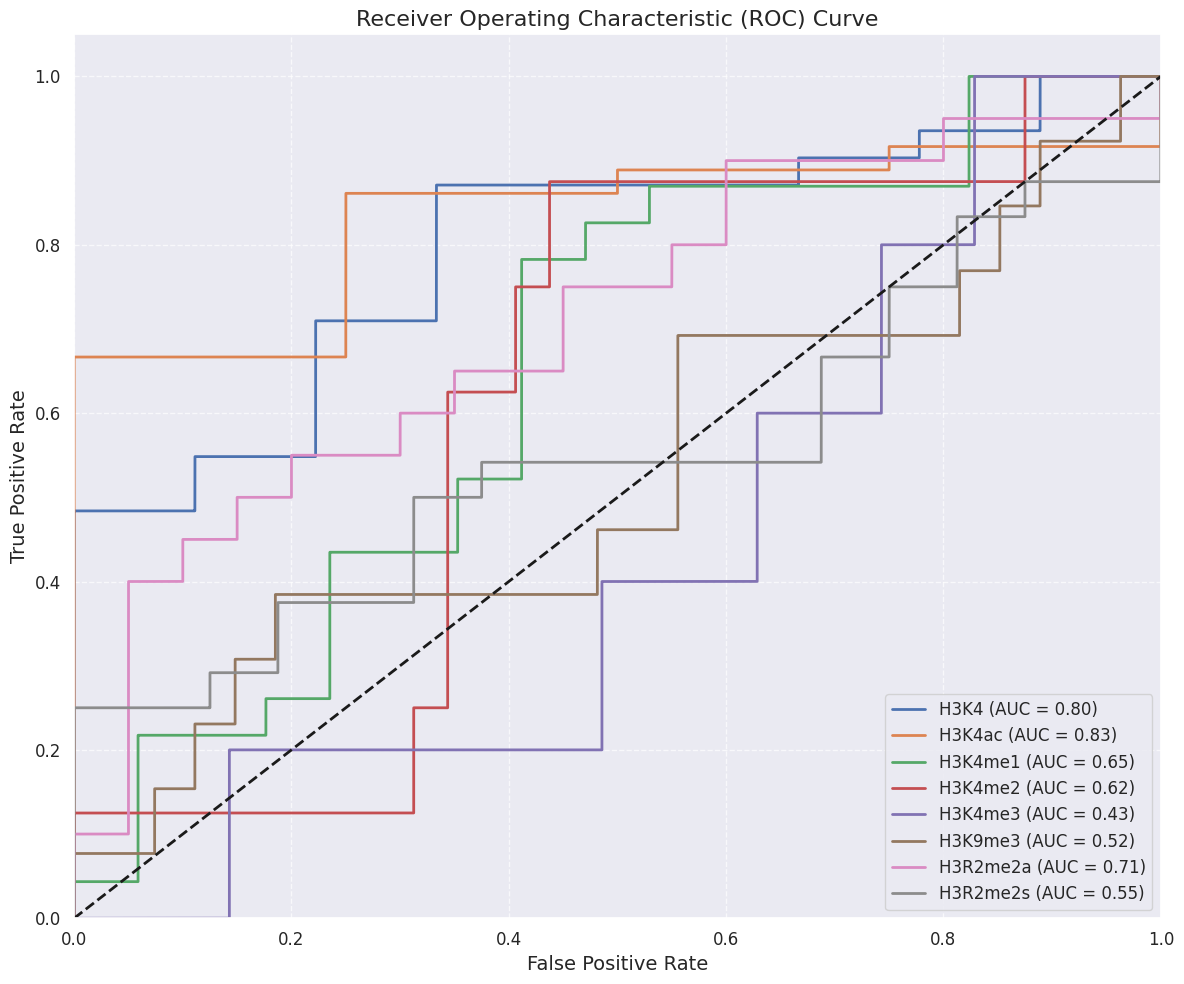

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy import interp

# Your existing code for preparing the data
targets = {}
for host, host_data in classification_results.items():
    for target, (pred_value, threshold, real_tag) in host_data.items():
        if target not in targets:
            targets[target] = {'y_true': [], 'y_score': []}
        targets[target]['y_true'].append(real_tag)
        targets[target]['y_score'].append(pred_value)

# Plot ROC curves
plt.figure(figsize=(12, 10))

for target, target_data in targets.items():
    y_true = np.array(target_data['y_true'])
    y_score = np.array(target_data['y_score'])
    
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    
    # Oversample points to create a smoother curve
    num_points = 10000
    indices = np.arange(len(fpr))
    interp_indices = np.linspace(0, len(fpr) - 1, num_points)
    
    interp_fpr = interp(interp_indices, indices, fpr)
    interp_tpr = interp(interp_indices, indices, tpr)
    
    # Ensure the curve starts at (0, 0) and ends at (1, 1)
    interp_fpr = np.concatenate(([0], interp_fpr, [1]))
    interp_tpr = np.concatenate(([0], interp_tpr, [1]))
    
    # Calculate AUC
    roc_auc = auc(interp_fpr, interp_tpr)
    
    # Plot the interpolated curve
    plt.plot(interp_fpr, interp_tpr, label=f'{target} (AUC = {roc_auc:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc="lower right", fontsize=12)

# Increase tick label size
plt.tick_params(axis='both', which='major', labelsize=12)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

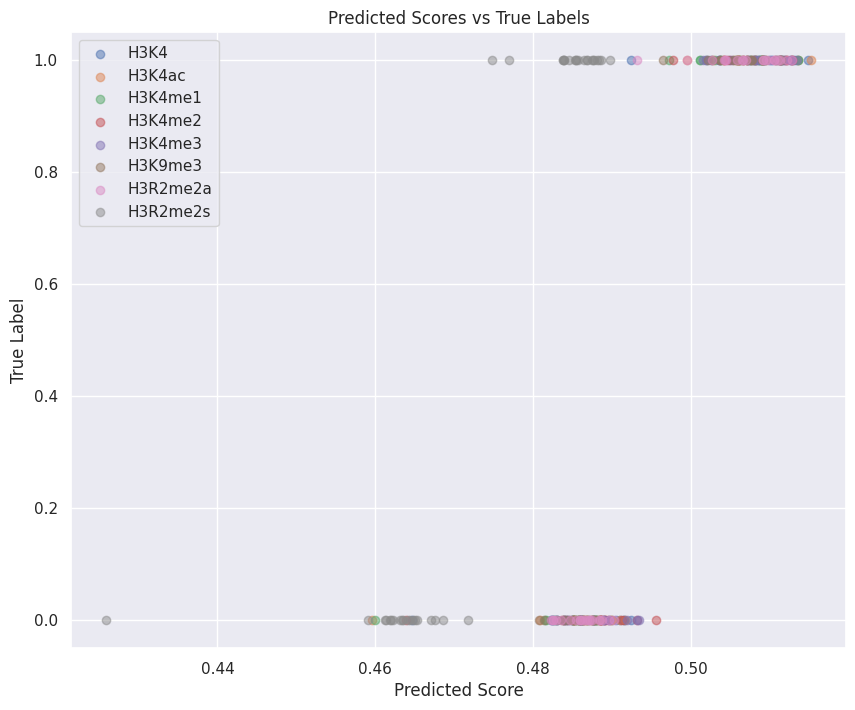

In [14]:
plt.figure(figsize=(10, 8))
for target, target_data in targets.items():
    y_true = np.array(target_data['y_true'])
    y_score = np.array(target_data['y_score'])
    
    plt.scatter(y_score, y_true, alpha=0.5, label=target)

plt.xlabel('Predicted Score')
plt.ylabel('True Label')
plt.title('Predicted Scores vs True Labels')
plt.legend()
plt.show()

In [15]:
for target, target_data in targets.items():
    y_true = np.array(target_data['y_true'])
    y_score = np.array(target_data['y_score'])
    
    print(f"\nTarget: {target}")
    print(f"True label distribution: {np.bincount(y_true)}")
    print(f"Predicted scores - Min: {y_score.min():.4f}, Max: {y_score.max():.4f}, Mean: {y_score.mean():.4f}")
    print(f"Unique predicted scores: {np.unique(y_score).size}")



Target: H3K4
True label distribution: [20 20]
Predicted scores - Min: 0.4646, Max: 0.5148, Mean: 0.4969
Unique predicted scores: 40

Target: H3K4ac
True label distribution: [20 20]
Predicted scores - Min: 0.4596, Max: 0.5152, Mean: 0.4970
Unique predicted scores: 40

Target: H3K4me1
True label distribution: [20 20]
Predicted scores - Min: 0.4600, Max: 0.5135, Mean: 0.4954
Unique predicted scores: 40

Target: H3K4me2
True label distribution: [20 20]
Predicted scores - Min: 0.4639, Max: 0.5128, Mean: 0.4974
Unique predicted scores: 40

Target: H3K4me3
True label distribution: [20 20]
Predicted scores - Min: 0.4824, Max: 0.5135, Mean: 0.4979
Unique predicted scores: 40

Target: H3K9me3
True label distribution: [20 20]
Predicted scores - Min: 0.4807, Max: 0.5114, Mean: 0.4960
Unique predicted scores: 40

Target: H3R2me2a
True label distribution: [20 20]
Predicted scores - Min: 0.4822, Max: 0.5128, Mean: 0.4965
Unique predicted scores: 40

Target: H3R2me2s
True label distribution: [19 21]



Target: H3K4
FPR shape: (6,), TPR shape: (6,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 0.9975

Target: H3K4ac
FPR shape: (4,), TPR shape: (4,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 1.0000

Target: H3K4me1
FPR shape: (4,), TPR shape: (4,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 1.0000

Target: H3K4me2
FPR shape: (4,), TPR shape: (4,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 1.0000

Target: H3K4me3
FPR shape: (4,), TPR shape: (4,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 1.0000

Target: H3K9me3
FPR shape: (4,), TPR shape: (4,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 1.0000

Target: H3R2me2a
FPR shape: (4,), TPR shape: (4,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 1.0000

Target: H3R2me2s
FPR shape: (4,), TPR shape: (4,)
FPR min/max: 0.0000/1.0000
TPR min/max: 0.0000/1.0000
AUC: 1.0000


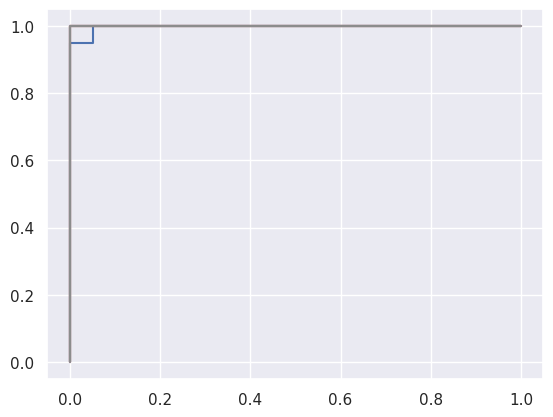

In [16]:
for target, target_data in targets.items():
    y_true = np.array(target_data['y_true'])
    y_score = np.array(target_data['y_score'])
    
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    print(f"\nTarget: {target}")
    print(f"FPR shape: {fpr.shape}, TPR shape: {tpr.shape}")
    print(f"FPR min/max: {fpr.min():.4f}/{fpr.max():.4f}")
    print(f"TPR min/max: {tpr.min():.4f}/{tpr.max():.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    plt.plot(fpr, tpr, label=f'{target} (AUC = {roc_auc:.2f})')


In [20]:
fpr, tpr, _ = roc_curve(y_true, -y_score)  

correlation = np.corrcoef(y_true, y_score)[0, 1]
print(f"Correlation between true labels and predictions: {correlation:.4f}")


Correlation between true labels and predictions: 0.8638


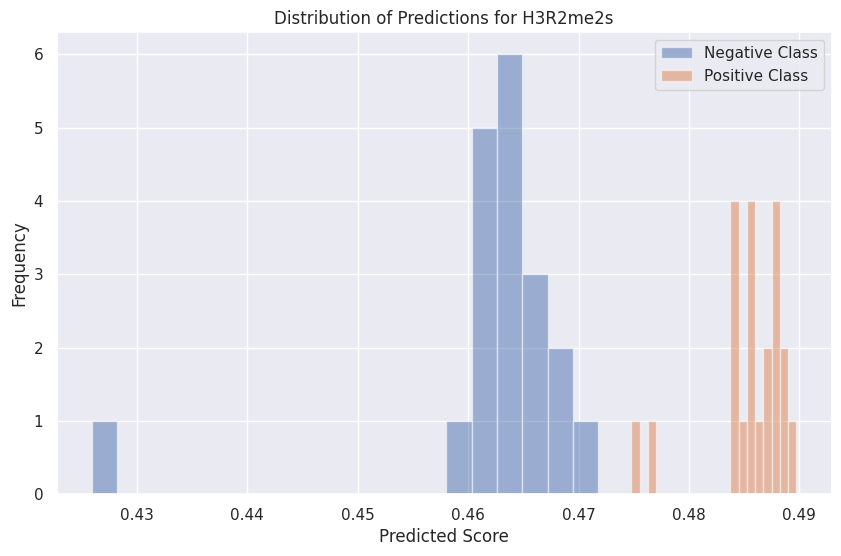

In [21]:
plt.figure(figsize=(10, 6))
plt.hist(y_score[y_true == 0], bins=20, alpha=0.5, label='Negative Class')
plt.hist(y_score[y_true == 1], bins=20, alpha=0.5, label='Positive Class')
plt.xlabel('Predicted Score')
plt.ylabel('Frequency')
plt.title(f'Distribution of Predictions for {target}')
plt.legend()
plt.show()


In [23]:


# Load your dataset
df = pd.read_csv('/notebooks/data/cal_abs.csv')

# 1. Categorical dataset based on individual column medians
df_cat_individual = df.copy()

for col in targets:
    median = df[col].median()
    df_cat_individual[col] = (df[col] >= median).astype(int)  # Changed > to >=

# Save the first categorical dataset
df_cat_individual.to_csv('categorical_individual_medians.csv', index=False)

# 2. Categorical dataset based on overall median
df_cat_overall = df.copy()

# Calculate the overall median of all target columns
overall_median = np.median(df[targets].values)

# Apply the overall median threshold to all target columns
for col in targets:
    df_cat_overall[col] = (df[col] >= overall_median).astype(int)  # Changed > to >=

# Save the second categorical dataset
df_cat_overall.to_csv('categorical_overall_median.csv', index=False)

print("Both categorical datasets have been created and saved.")

# Optional: Print the distribution of 0s and 1s for each column
for col in targets:
    print(f"\nDistribution for {col}:")
    print(df_cat_individual[col].value_counts(normalize=True))

print("\nOverall distribution:")
for col in targets:
    print(f"\nDistribution for {col}:")
    print(df_cat_overall[col].value_counts(normalize=True))

Both categorical datasets have been created and saved.

Distribution for H3K4:
H3K4
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution for H3K4ac:
H3K4ac
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution for H3K4me1:
H3K4me1
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution for H3K4me2:
H3K4me2
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution for H3K4me3:
H3K4me3
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution for H3K9me3:
H3K9me3
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution for H3R2me2a:
H3R2me2a
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribution for H3R2me2s:
H3R2me2s
1    0.525
0    0.475
Name: proportion, dtype: float64

Overall distribution:

Distribution for H3K4:
H3K4
1    0.775
0    0.225
Name: proportion, dtype: float64

Distribution for H3K4ac:
H3K4ac
1    0.9
0    0.1
Name: proportion, dtype: float64

Distribution for H3K4me1:
H3K4me1
1    0.575
0    0.425
Name: pro

In [13]:
df = pd.read_csv('/notebooks/data/categorical_individual_medians.csv')

for i in targets:
    print(df[i].value_counts())

H3K4
0    20
1    20
Name: count, dtype: int64
H3K4ac
0    20
1    20
Name: count, dtype: int64
H3K4me1
0    20
1    20
Name: count, dtype: int64
H3K4me2
0    20
1    20
Name: count, dtype: int64
H3K4me3
0    20
1    20
Name: count, dtype: int64
H3K9me3
0    20
1    20
Name: count, dtype: int64
H3R2me2a
0    20
1    20
Name: count, dtype: int64
H3R2me2s
1    21
0    19
Name: count, dtype: int64
